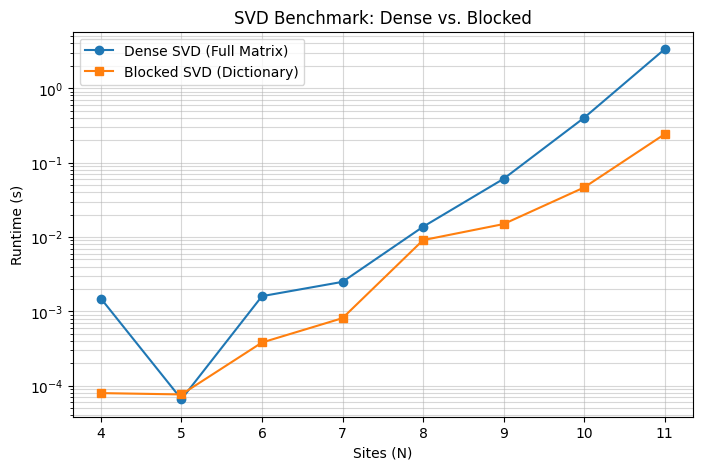

Blocked SVD is 13.88x faster.


In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt


def get_sz_sectors(n_sites):
    sectors = {}
    for i in range(2**n_sites):
        sz = sum([0.5 if b == "0" else -0.5 for b in bin(i)[2:].zfill(n_sites)])
        if sz not in sectors:
            sectors[sz] = []
        sectors[sz].append(i)
    return sectors


def block_svd_truncated(blocks: dict[int, np.ndarray], k: int | None):
    u_full, s_full, vh_full = {}, {}, {}
    all_s_values = []

    for q, matrix in blocks.items():
        u, s, vh = np.linalg.svd(matrix, full_matrices=False)
        u_full[q] = u
        s_full[q] = s
        vh_full[q] = vh
        all_s_values.append(s)

    flat_s = np.concatenate(all_s_values)
    flat_s[::-1].sort()

    actual_k = min(k, len(flat_s)) if k is not None else len(flat_s)
    epsilon = flat_s[actual_k - 1]

    u_trunc, s_trunc, vh_trunc = {}, {}, {}

    for q in s_full:
        mask = s_full[q] >= epsilon
        u_trunc[q] = u_full[q][:, mask]
        s_trunc[q] = s_full[q][mask]
        vh_trunc[q] = vh_full[q][mask, :]
    return u_trunc, s_trunc, vh_trunc


def run_benchmark(n_sites):
    dim = 2**n_sites
    sectors = get_sz_sectors(n_sites)

    blocked_data = {
        q: np.random.randn(len(idx), len(idx)) for q, idx in sectors.items()
    }

    dense_matrix = np.zeros((dim, dim))
    curr = 0
    for q in sorted(sectors.keys()):
        size = len(sectors[q])
        dense_matrix[curr : curr + size, curr : curr + size] = blocked_data[q]
        curr += size

    start = time.perf_counter()
    _ = np.linalg.svd(dense_matrix, full_matrices=False)
    dense_time = time.perf_counter() - start

    start = time.perf_counter()
    for q in blocked_data:
        _ = np.linalg.svd(blocked_data[q], full_matrices=False)
    blocked_time = time.perf_counter() - start

    return dense_time, blocked_time


sizes = [4, 5, 6, 7, 8, 9, 10, 11]
results = [run_benchmark(s) for s in sizes]
dense_res, block_res = zip(*results)

plt.figure(figsize=(8, 5))
plt.plot(sizes, dense_res, "o-", label="Dense SVD (Full Matrix)")
plt.plot(sizes, block_res, "s-", label="Blocked SVD (Dictionary)")
plt.yscale("log")
plt.xlabel("Sites (N)")
plt.ylabel("Runtime (s)")
plt.title("SVD Benchmark: Dense vs. Blocked")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

speedup = dense_res[-1] / block_res[-1]
print(f"Blocked SVD is {speedup:.2f}x faster.")

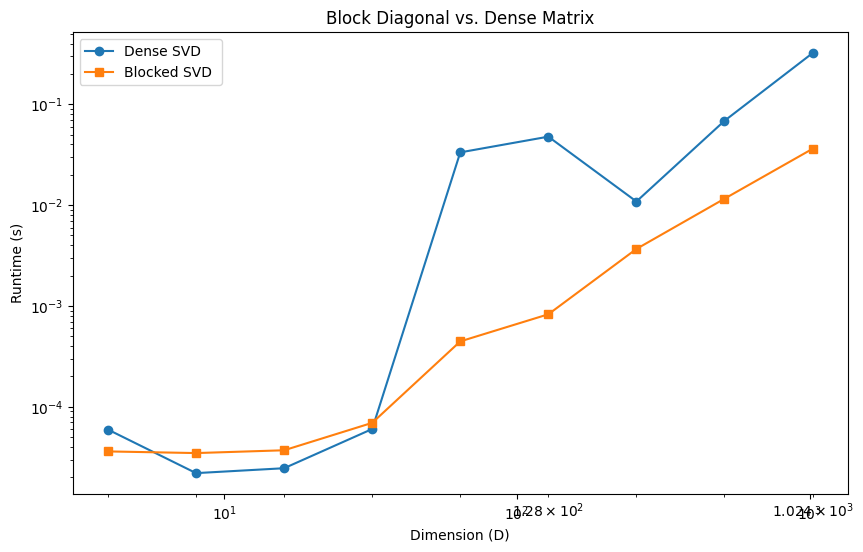

speedpu at D=1024: 8.89x


In [2]:
def generate_random_block_sizes(total_dim, num_blocks):
    cuts = np.sort(np.random.choice(range(1, total_dim), num_blocks - 1, replace=False))
    sizes = np.diff(np.concatenate(([0], cuts, [total_dim])))
    return sizes

def run_pure_benchmark(total_dim, num_blocks):
    block_sizes = generate_random_block_sizes(total_dim, num_blocks)
    blocked_data = [np.random.randn(s, s) for s in block_sizes]
    
    dense_matrix = np.zeros((total_dim, total_dim))
    curr = 0
    for block in blocked_data:
        size = block.shape[0]
        dense_matrix[curr:curr+size, curr:curr+size] = block
        curr += size

    start = time.perf_counter()
    _ = np.linalg.svd(dense_matrix, full_matrices=False)
    dense_time = time.perf_counter() - start

    start = time.perf_counter()
    for block in blocked_data:
        _ = np.linalg.svd(block, full_matrices=False)
    blocked_time = time.perf_counter() - start

    return dense_time, blocked_time


n_range = range(2,11) 
total_dims = [2**n for n in n_range]
num_blocks = [n + 1 for n in n_range] # Justify the n+1 for this.

results = [run_pure_benchmark(d, b) for (d,b) in zip(total_dims, num_blocks)]
dense_res, block_res = zip(*results)

plt.figure(figsize=(10, 6))
plt.plot(total_dims, dense_res, "o-", label="Dense SVD")
plt.plot(total_dims, block_res, "s-", label="Blocked SVD ")
plt.yscale("log")
plt.xscale("log") 
plt.xticks(total_dims, minor=True)
plt.xlabel("Dimension (D)")
plt.ylabel("Runtime (s)")
plt.title("Block Diagonal vs. Dense Matrix")
plt.legend()
plt.show()

print(f"speedpu at D={total_dims[-1]}: {dense_res[-1]/block_res[-1]:.2f}x")